# Business Performance Analysis in Yandex.Afisha

    Analyzed data is taken from Yandex.Afisha from June 2017 to the end of May 2018.
    Goal: to help marketers optimize marketing costs.
    Find optimal sources/platforms.

## Contents:
* [Step 1. General Information](#1-bullet)
* [Step 2. Data Preprocessing](#2-bullet)
* 2.1. [Renaming Columns](#2-1-bullet)
* 2.2. [Changing Data Types](#2-2-bullet)
* [Step 3. Building Reports and Calculating Metrics](#3-bullet)
* 3.1. [Product](#3-1-bullet)
* [DAU, WAU, MAU](#3-1-1-bullet)
* [Stickiness](#3-1-2-bullet)
* [ASL or Average Session Lasting](#3-1-3-bullet)
* [Retention Rate by Visit](#3-1-4-bullet)
* 3.2. [Sales](#3-2-bullet)
* [How Long Does It Take to Make a Purchase](#3-2-1-bullet)
* [How Many Times Do Customers Buy During the Period](#3-2-2-bullet)
* [Average Order Value by Month in Cohorts](#3-2-3-bullet)
* [Retention Rate by Purchase](#3-2-4-bullet)
* [Economics of One Customer: LTV, CAC, ROMI](#3-2-5-bullet)
* 3.3. [Marketing](#3-3-bullet)
* [Advertising Costs](#3-3-1-bullet)
* [Cost per Customer Acquisition](#3-3-2-bullet)
* [ROMI, Return on Advertising Spend](#3-3-3-bullet)
* [Analysis of Resource Traffic by Device Type](#3-3-4-bullet)
* [Step 4. General Conclusion](#4-bullet)

## Step 1. General Information <a class="anchor" id="1-bullet"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter  

In [2]:
visits = pd.read_csv('https://code.s3.yandex.net/datasets/visits_log.csv')
visits.head(7)

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451


***Visits table (server log with information about website visits):***

* Uid — Unique User Identifier
* Device — User Device Category
* Start Ts — Session Start Date and Time
* End Ts — Session End Date and Time
* Source Id — Identifier of the Advertising Source

In [4]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


   
    The visits table contains 359 400 rows, with no missing values.
    In the ['End Ts'] and ['Start Ts'] columns, the data type must be changed to datetime.
    For ease of use, the columns must be renamed and converted to lowercase.

In [5]:
orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders_log.csv')
orders.head(7)

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638


***Orders table (order information):***

* Uid — Unique User ID
* Buy Ts — Order Date and Time
* Revenue — Yandex.Afisha Revenue from This Order

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


    The orders table contains 50 415 rows, with no missing values.
    In the ['Buy Ts'] column, the data type must be changed to datetime.
    For ease of use, the columns must be renamed and converted to lowercase.

In [7]:
costs = pd.read_csv('https://code.s3.yandex.net/datasets/costs.csv')
costs.head(7)

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59


***Costs table (marketing cost information):***

* source_id — Advertising Source ID
* dt — Date
* costs — Costs for This Advertising Source on this Day

In [8]:
costs['source_id'].unique()

array([ 1,  2,  3,  4,  5,  9, 10])

In [9]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


    The table contains 2 542 rows, with no missing values.
    In the ['dt'] column, you need to change the data type to datetime and rename the column.


### Step 2. Data Preprocessing<a class="anchor" id="2-bullet"></a>

### 2.1 Renaming Columns<a class="anchor" id="2-1-bullet"></a>

In [10]:
visits.columns = ['device','session_end_t', 'source_id', 'session_start_t', 'uid']
visits.head()

,device,session_end_t,source_id,session_start_t,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [11]:
orders.rename(columns={'Buy Ts': 'order_date_t', 'Revenue': 'revenue', 'Uid': 'uid'}, inplace=True)
orders.head()

,order_date_t,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [12]:
costs.rename(columns={'dt': 'date'}, inplace=True)
costs.head()

,source_id,date,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


### 2.2 Changing Data Types<a class="anchor" id="2-2-bullet"></a>

In [13]:
visits['session_end_t'] = pd.to_datetime(visits['session_end_t'])

visits['session_start_t'] = pd.to_datetime(visits['session_start_t'])

visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   device           359400 non-null  object        
 1   session_end_t    359400 non-null  datetime64[ns]
 2   source_id        359400 non-null  int64         
 3   session_start_t  359400 non-null  datetime64[ns]
 4   uid              359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [14]:
visits.head()

,device,session_end_t,source_id,session_start_t,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [15]:
orders['order_date_t'] = pd.to_datetime(orders['order_date_t'])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_date_t  50415 non-null  datetime64[ns]
 1   revenue       50415 non-null  float64       
 2   uid           50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [15]:
orders.head()

,order_date_t,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [16]:
costs['date'] = pd.to_datetime(costs['date'])
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   date       2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


## Step 3. Building Reports and Calculating Metrics<a class="anchor" id="3-bullet"></a>

### 3.1. Product<a class="anchor" id="3-1-bullet"></a>

### DAU, WAU, MAU

In [19]:
visits['day'] = visits['session_start_t'].dt.date
visits['week'] = visits['session_start_t'].dt.isocalendar().week
visits['month'] = visits['session_start_t'].dt.month
visits['year']  = visits['session_start_t'].dt.year


In [20]:
visits.head(5)

,device,session_end_t,source_id,session_start_t,uid,day,week,month,year
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,51,12,2017
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,8,2,2018
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,7,2017
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,5,2018
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,52,12,2017


In [21]:
visits['day'] = pd.to_datetime(visits['day'])

In [22]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   device           359400 non-null  object        
 1   session_end_t    359400 non-null  datetime64[ns]
 2   source_id        359400 non-null  int64         
 3   session_start_t  359400 non-null  datetime64[ns]
 4   uid              359400 non-null  uint64        
 5   day              359400 non-null  datetime64[ns]
 6   week             359400 non-null  UInt32        
 7   month            359400 non-null  int64         
 8   year             359400 non-null  int64         
dtypes: UInt32(1), datetime64[ns](3), int64(3), object(1), uint64(1)
memory usage: 23.6+ MB


### Calculating DAU, WAU, MAU<a class="anchor" id="3-1-1-bullet"></a>

In [23]:
dau_total = visits.groupby('day').agg({'uid': 'nunique'}).mean()
dau_total = dau_total.round()
print('DAU, number of unique users daily:', dau_total)

DAU, number of unique users daily: uid    908.0
dtype: float64


In [24]:
wau_total = visits.groupby(['year', 'week']).agg({'uid': 'nunique'}).mean()
wau_total = wau_total.round()
print('WAU, number of unique users weekly:', wau_total)

WAU, number of unique users weekly: uid    5716.0
dtype: float64


In [25]:
mau_total = visits.groupby(['year', 'month']).agg({'uid': 'nunique'}).mean()
mau_total = mau_total.round()
print('MAU, number of unique users monthly:', mau_total)

MAU, number of unique users monthly: uid    23228.0
dtype: float64


   
**Let's look at the dynamics of changes in the number of unique users per month MAU**

In [26]:
dynamics_mau_total = visits.groupby(['year', 'month']).agg({'uid': 'nunique'}).round()
dynamics_mau_total.head(15)

uid
year month       
2017 6      13259
     7      14183
     8      11631
     9      18975
     10     29692
     11     32797
     12     31557
2018 1      28716
     2      28749
     3      27473
     4      21008
     5      20701

Text(0.5, 1.0, 'Number of Unique Users Daily')

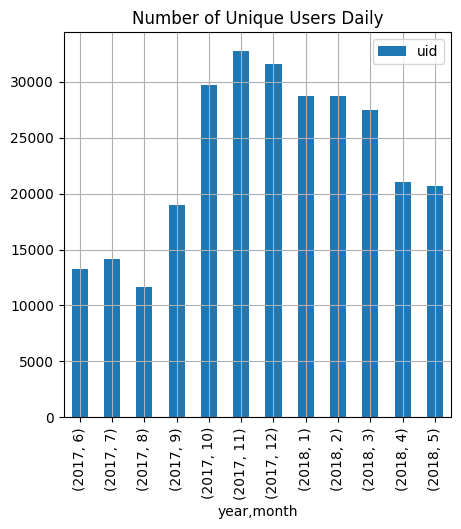

In [27]:
dynamics_mau_total = visits.groupby(['year', 'month']).agg({'uid': 'nunique'}).plot(kind='bar', grid=True, figsize=(5, 5))
plt.title('Number of Unique Users Daily')

Dynamics:
* June, July, and August 2017 - the average number of unique users per month does not exceed 14 200.
* The number begins to increase in September 2017.
* The maximum number of unique users per day occurs in November 2017 (32 797).
* The decline begins in April and May 2019.

### Stickiness<a class="anchor" id="3-1-2-bullet"></a>

In [28]:
sticky_mau = dau_total / mau_total * 100
sticky_wau = dau_total / wau_total * 100
print('Stickiness (Weekly)', sticky_wau.round(1))
print('Stickiness (Monthly)', sticky_mau.round(1))

Stickiness (Weekly) uid    15.9
dtype: float64
Stickiness (Monthly) uid    3.9
dtype: float64


    Sticky factor is an indicator of audience loyalty to a service.
    It shows the frequency and regularity of service use over the course of a week or month.

    A monthly sticky factor of around 18% is considered normal.
    In this case, it's 3.9%. If each user logged in only once during the month, the sticky factor is 3.3%. The higher this figure, the more regularly users log in to the app.

### ASL or Average Session Lasting<a class="anchor" id="3-1-3-bullet"></a>

In [29]:
visits['session_duration_sec'] = (visits['session_end_t'] - visits['session_start_t']).dt.seconds
print(visits['session_duration_sec'].mean().round(2))

643.51


<AxesSubplot:>

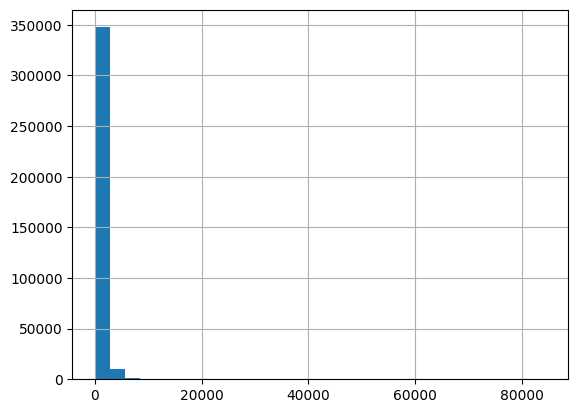

In [30]:
visits['session_duration_sec'].hist(bins=30)

    When the distribution is close to normal or normal, we can look at the mean
    or median. However, this distribution is not normal, so we'll calculate the mode
    (the value in the sample that occurs most frequently):

In [31]:
print(visits['session_duration_sec'].mode())

0    60
dtype: int64


    The average session lasting is 60 seconds.

### How many sessions per day?

In [32]:
sessions_per_user = visits.groupby(['year', 'day']).agg({'uid': ['count','nunique']}).mean()
print(sessions_per_user.round())

uid  count      987.0
     nunique    908.0
dtype: float64


    On average, 985 sessions are performed per day, 906 of which are from unique users.


    
**Let's look at the dynamics of sessions conducted per day**
    

In [33]:
sessions_per_user_1 = visits.groupby(['year', 'month', 'day']).agg({'uid':['count', 'nunique']})

In [34]:
sessions_per_user_1.columns = ['count', 'n_sessions_per_day']

In [35]:
sessions_per_user_1.groupby(['year', 'month']).agg({'n_sessions_per_day':'mean'}).round()

n_sessions_per_day
year month                    
2017 6                   511.0
     7                   532.0
     8                   433.0
     9                   739.0
     10                 1133.0
     11                 1329.0
     12                 1241.0
2018 1                  1097.0
     2                  1217.0
     3                  1053.0
     4                   846.0
     5                   786.0

Text(0.5, 1.0, 'Number of Sessions per Day')

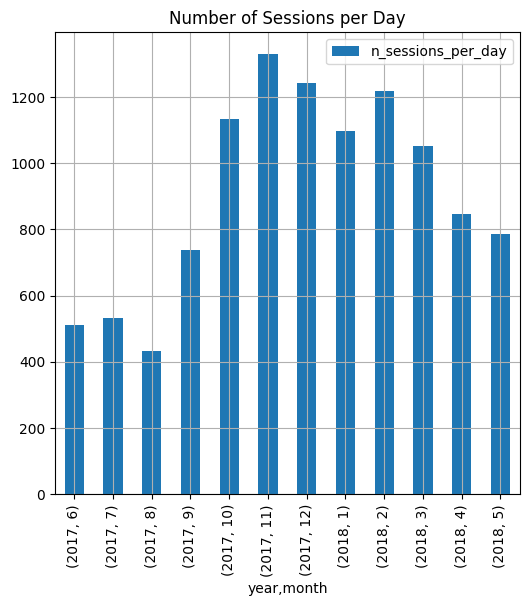

In [36]:
sessions_per_user_1.groupby(['year', 'month']).agg({'n_sessions_per_day':'mean'}).plot(kind='bar', grid=True, figsize=(6, 6))
plt.title('Number of Sessions per Day')

   
    Based on daily session dynamics:
    * June, July, and August 2017 - the average number of sessions per day does not exceed 550.
    * The number of sessions begins to increase in September 2017.
    * The maximum number of sessions per day occurs in November 2017 (1 329 on average).
    * A noticeable decline begins in April and May 2019.

### How often do people come back?

In [37]:
visits['session_end_wt'] = pd.to_datetime(visits['session_end_t']).dt.normalize()
visits['session_start_wt'] = pd.to_datetime(visits['session_start_t']).dt.normalize()

In [38]:
first_visit_date = visits.groupby(['uid'])['session_start_wt'].min()
first_visit_date.name = 'first_visit_date'
visits = visits.join(first_visit_date,on='uid')
visits.head()

,device,session_end_t,source_id,session_start_t,uid,day,week,month,year,session_duration_sec,session_end_wt,session_start_wt,first_visit_date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,51,12,2017,1080,2017-12-20,2017-12-20,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,8,2,2018,1680,2018-02-19,2018-02-19,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,7,2017,0,2017-07-01,2017-07-01,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,5,2018,1440,2018-05-20,2018-05-20,2018-03-09
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,52,12,2017,0,2017-12-27,2017-12-27,2017-12-27


In [39]:
visits['activity_montn'] = visits['session_start_wt'].astype('datetime64[M]')
visits['first_activity_month'] = visits['first_visit_date'].astype('datetime64[M]')

In [40]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   device                359400 non-null  object        
 1   session_end_t         359400 non-null  datetime64[ns]
 2   source_id             359400 non-null  int64         
 3   session_start_t       359400 non-null  datetime64[ns]
 4   uid                   359400 non-null  uint64        
 5   day                   359400 non-null  datetime64[ns]
 6   week                  359400 non-null  UInt32        
 7   month                 359400 non-null  int64         
 8   year                  359400 non-null  int64         
 9   session_duration_sec  359400 non-null  int64         
 10  session_end_wt        359400 non-null  datetime64[ns]
 11  session_start_wt      359400 non-null  datetime64[ns]
 12  first_visit_date      359400 non-null  datetime64[ns]
 13 

   
**Let's look at the number of users in each cohort**

In [41]:
cohort_grouped = visits.groupby('first_activity_month').agg({'uid':'nunique','session_start_wt':'count'}).reset_index()
cohort_grouped.columns = ['cohort', 'qty_users', 'qty_sessions']
cohort_grouped.head(15)

,cohort,qty_users,qty_sessions
0,2017-06-01,13259,40863
1,2017-07-01,13140,25370
2,2017-08-01,10181,18671
3,2017-09-01,16704,28795
4,2017-10-01,25977,41682
5,2017-11-01,27248,44383
6,2017-12-01,25268,36258
7,2018-01-01,22624,31189
8,2018-02-01,22197,29099
9,2018-03-01,20589,26269


    Since December 2017, the number of users in each subsequent cohort has been declining.
    This means that Yandex.Afisha is attracting fewer and fewer new users over time.

    The peak number of visits occurs in the October and November cohorts. Subsequently, the number of visits for each subsequent cohort
    is lower than the previous one. This is logical, as older cohorts have been around longer, and users from them have been visiting
    for a longer period.


**Let's look at the number of user visits in each cohort by month**

In [42]:
visits.pivot_table(index='first_activity_month', columns='activity_montn', values='uid', aggfunc='nunique')

activity_montn,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01
first_activity_month,,,,,,,,,,,,
2017-06-01,13259.0,1043.0,713.0,814.0,909.0,947.0,809.0,766.0,694.0,674.0,539.0,596.0
2017-07-01,NaN,13140.0,737.0,674.0,738.0,765.0,633.0,596.0,601.0,510.0,376.0,361.0
2017-08-01,NaN,NaN,10181.0,783.0,640.0,639.0,510.0,448.0,370.0,402.0,284.0,265.0
2017-09-01,NaN,NaN,NaN,16704.0,1428.0,1156.0,847.0,658.0,632.0,599.0,404.0,381.0
2017-10-01,NaN,NaN,NaN,NaN,25977.0,2042.0,1357.0,1012.0,890.0,837.0,555.0,529.0
2017-11-01,NaN,NaN,NaN,NaN,NaN,27248.0,2133.0,1202.0,1054.0,919.0,638.0,594.0
2017-12-01,NaN,NaN,NaN,NaN,NaN,NaN,25268.0,1410.0,960.0,786.0,512.0,481.0
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22624.0,1351.0,890.0,565.0,458.0
2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22197.0,1267.0,565.0,446.0


* After the first month, the number of visitors in a cohort drops sharply.
* The October and November cohorts have the highest number of visitors per month, and then the number decreases less per month than in other cohorts.
* The June 2017 cohort has approximately the same number of visits as the "maximum" cohorts of October and November 2017.



### Retention Rate by Visit <a class="anchor" id="3-1-4-bullet"></a>

In [43]:
visits['activity_montn'] = visits['session_start_wt'].astype('datetime64[M]')
visits['first_activity_month'] = visits['first_visit_date'].astype('datetime64[M]')

In [44]:
visits['cohort_lifetime'] = visits['activity_montn'] - visits['first_activity_month']

In [45]:
visits['cohort_lifetime'] = visits['cohort_lifetime'] / np.timedelta64(1,'M')
visits['cohort_lifetime'] = visits['cohort_lifetime'].round().astype(int)

In [46]:
visits_cohorts = visits.groupby(['first_activity_month','cohort_lifetime']).agg({'uid':'nunique'}).reset_index()

In [47]:
visits_inital_users_count = visits_cohorts[visits_cohorts['cohort_lifetime'] == 0][['first_activity_month','uid']]

In [48]:
visits_inital_users_count = visits_inital_users_count.rename(columns={'uid':'cohort_users'})

In [49]:
visits_cohorts = visits_cohorts.merge(visits_inital_users_count,on='first_activity_month')

In [50]:
visits_cohorts['retention'] = visits_cohorts['uid']/visits_cohorts['cohort_users']

In [51]:
visits_retention_pivot = visits_cohorts.pivot_table(index='first_activity_month',columns='cohort_lifetime',values='retention',aggfunc='sum')

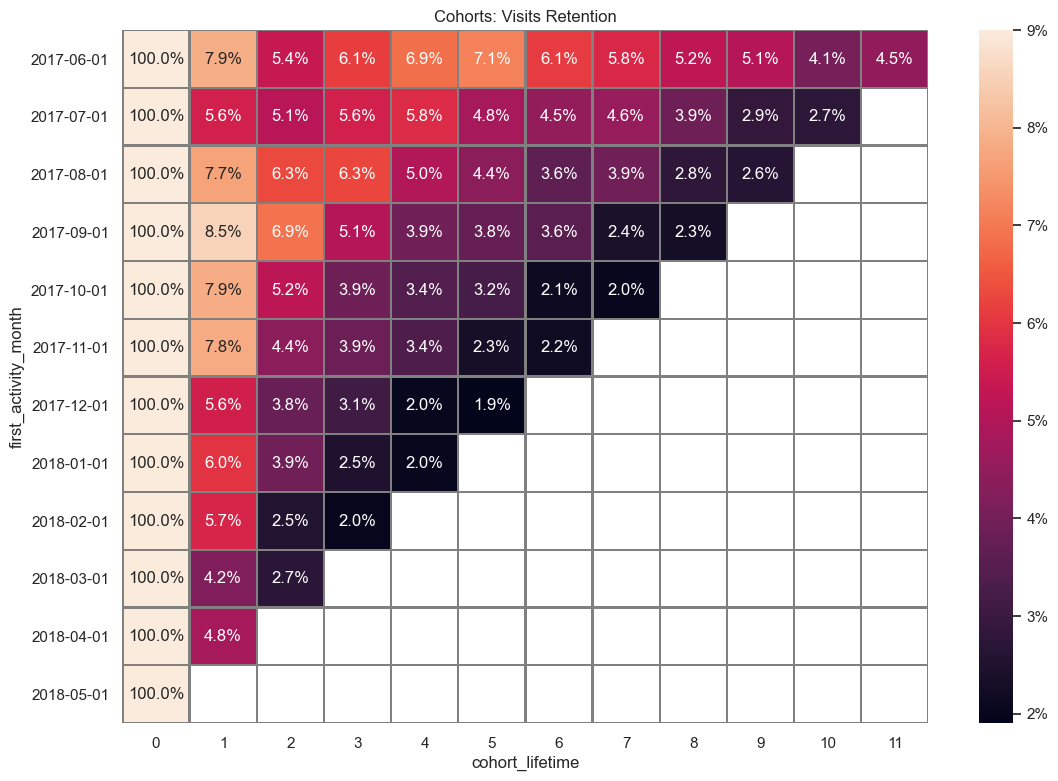

In [53]:
sns.set(style='white')
plt.figure(figsize=(13, 9))
plt.title('Cohorts: Visits Retention')
fmt = lambda x,pos: '{:.0%}'.format(x) 
heatmap = sns.heatmap(visits_retention_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='gray', vmax=0.09,
            cbar_kws={'format': FuncFormatter(fmt)})

y_labels = heatmap.set_yticklabels(visits_retention_pivot.index.date)  

In the first month, we see a low retention rate:

* before December 2017 - from 7.7% to 8.5% (except for July 2017 - 5.6%)

* since December 2017 - from 6% to 4.2%

This is an important signal that we need to focus on customer retention in the first month, as the majority
of active customers abandon the service during this period.

The highest retention rate in the first month was in the September 2017 cohort (8.5%).

In seven cohorts, the retention rate consistently declined each month (these are the cohorts from September 2017 to March 2018). We exclude April from the calculation, as the cohort is one month old.

In three cohorts, there was an increase after the decline. It is necessary to further study what led to the increase in visits in these months.

* June 2017 - growth at 3, 4, and 5 months of age
* July 2017 - growth at 3, 4, and 7 months of age
* August 2017 - growth at 7 months of age

The first cohort has the highest retention rate even after one year of life - 4.5%.

### 3.2. Sales <a class="anchor" id="3-2-bullet"></a>

### How Long Does It Take to Make a Purchase<a class="anchor" id="3-2-1-bullet"></a>

In [54]:
pd.to_datetime(orders['order_date_t'], format='%Y.%m.%d')
orders['date'] = pd.to_datetime(orders['order_date_t']).dt.normalize()

In [55]:
first_order_date_by_customers = orders.groupby('uid')['date'].min()
first_order_date_by_customers.name = 'first_order_date'
orders = orders.join(first_order_date_by_customers,on='uid')

In [56]:
orders.head()

,order_date_t,revenue,uid,date,first_order_date
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01


In [57]:
sales = orders.merge(visits, on='uid', how='left')
sales.head()

,order_date_t,revenue,uid,date,first_order_date,device,session_end_t,source_id,session_start_t,day,week,month,year,session_duration_sec,session_end_wt,session_start_wt,first_visit_date,activity_montn,first_activity_month,cohort_lifetime
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01,2017-06-01,desktop,2017-06-01 00:11:00,1,2017-06-01 00:09:00,2017-06-01,22,6,2017,120,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2017-06-01,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01,2017-06-01,desktop,2017-06-01 00:25:00,2,2017-06-01 00:14:00,2017-06-01,22,6,2017,660,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2017-06-01,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01,2017-06-01,desktop,2017-06-01 00:34:00,2,2017-06-01 00:25:00,2017-06-01,22,6,2017,540,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2017-06-01,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01,2017-06-01,desktop,2017-06-01 00:33:00,2,2017-06-01 00:14:00,2017-06-01,22,6,2017,1140,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2017-06-01,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01,2017-06-01,desktop,2017-06-01 07:59:00,3,2017-06-01 07:31:00,2017-06-01,22,6,2017,1680,2017-06-01,2017-06-01,2017-06-01,2017-06-01,2017-06-01,0


In [59]:
new_sales = sales[(sales['session_end_t'] >= sales['order_date_t']) &
(sales['session_start_t'] <= sales ['order_date_t'])]

In [60]:
new_sales.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 35927 entries, 0 to 761806
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_date_t          35927 non-null  datetime64[ns]
 1   revenue               35927 non-null  float64       
 2   uid                   35927 non-null  uint64        
 3   date                  35927 non-null  datetime64[ns]
 4   first_order_date      35927 non-null  datetime64[ns]
 5   device                35927 non-null  object        
 6   session_end_t         35927 non-null  datetime64[ns]
 7   source_id             35927 non-null  int64         
 8   session_start_t       35927 non-null  datetime64[ns]
 9   day                   35927 non-null  datetime64[ns]
 10  week                  35927 non-null  UInt32        
 11  month                 35927 non-null  int64         
 12  year                  35927 non-null  int64         
 13  session_duratio

In [61]:
sales['order_duration_day'] = (sales['order_date_t'] - sales['session_start_t'])

In [62]:
print(sales['order_duration_day'].mode())

0   0 days 00:01:00
dtype: timedelta64[ns]


    On average, users start buying within a minute of starting a session. This means they know exactly what they want to buy. As we previously found, the average session duration is 60 seconds.
    

### How Many Times Do Customers Buy During the Period<a class="anchor" id="3-2-2-bullet"></a>

In [63]:
orders['first_order_month'] = orders['first_order_date'].astype('datetime64[M]')
orders['order_month'] = orders['date'].astype('datetime64[M]')

In [64]:
sales_cohort_grouped = sales.groupby('first_activity_month').agg({'uid':'nunique','revenue':'sum'}).round().reset_index()
sales_cohort_grouped.columns = ['cohort', 'qty_buyers', 'total_revenue']
sales_cohort_grouped

,cohort,qty_buyers,total_revenue
0,2017-06-01,2923,3929833.0
1,2017-07-01,2458,168692.0
2,2017-08-01,1721,544189.0
3,2017-09-01,3058,1229545.0
4,2017-10-01,4678,171036.0
5,2017-11-01,4262,247140.0
6,2017-12-01,4074,217507.0
7,2018-01-01,3119,134109.0
8,2018-02-01,3186,81970.0
9,2018-03-01,2838,145269.0


    Since December 2017, the number of buyers in each subsequent cohort has been declining.
    This means that Yandex.Afisha is attracting fewer and fewer new buyers over time.

    The highest sales total is in the 2017-06-01 cohort. This is logical, as the older cohort has been around longer,
    and users in them have been making purchases for a longer period.

    The 2017-09-01 cohort also stands out in terms of sales total, coming in second.
    Let's also note the 2018-03-01 cohort, which has surpassed the older 2018-02-01 and 2018-01-01 cohorts in terms of sales total.

**Let's look at sales in each cohort by month**

In [65]:
sales.pivot_table(index='first_activity_month', columns='activity_montn', values='revenue', aggfunc='sum')

activity_montn,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01
first_activity_month,,,,,,,,,,,,
2017-06-01,253324.55,190867.58,184169.16,340679.26,410873.97,434235.59,506566.74,370934.66,340889.52,354163.37,259974.11,283154.87
2017-07-01,NaN,33063.40,11643.67,17275.44,18595.50,18754.31,14325.42,10864.65,7524.36,8122.87,19561.99,8960.75
2017-08-01,NaN,NaN,32645.36,55625.03,40025.20,67131.85,51500.21,33253.72,29229.54,63822.36,80888.14,90068.00
2017-09-01,NaN,NaN,NaN,276332.49,65806.59,130026.74,391614.48,63855.00,170666.63,69010.89,52765.57,9466.58
2017-10-01,NaN,NaN,NaN,NaN,61675.65,31435.79,13267.23,13754.39,13146.93,9304.25,7605.05,20846.85
2017-11-01,NaN,NaN,NaN,NaN,NaN,52090.09,53138.31,38698.74,52499.23,31983.23,9721.91,9008.82
2017-12-01,NaN,NaN,NaN,NaN,NaN,NaN,61403.61,46009.04,25787.09,65573.87,9485.87,9247.20
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31549.91,49106.70,25602.59,14017.83,13832.10
2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38028.37,23648.52,8756.85,11536.37


* After the first month, the number of purchases in a cohort decreases. The exceptions are three cohorts, which saw an increase in the month following the first month: 2017-08-01, 2018-01-01, and 2018-03-01.

* The first cohort generates the most revenue, even after a year of cohort existence.

* Note the 2017-09-01 cohort. This cohort has its highest sales in its first month. Even in the first cohort, sales are lower in the first month. There was strong growth in months 3, 4, and 5.

**Let's look at the number of purchases per user over time by month**

In [66]:
orders_per_user = sales.groupby(['year', 'month']).agg({'uid':'nunique', 'order_date_t':'count'})
orders_per_user.columns = ['uid', 'n_orders_per_month']
orders_per_user.round()

uid  n_orders_per_month
year month                          
2017 6      2923               25988
     7      2893               28986
     8      2282               32564
     9      3960               60757
     10     6251               71483
     11     6471               72420
     12     6629              102912
2018 1      5504               77651
     2      5687               82787
     3      5458               75988
     4      3857               60157
     5      4328               70114

In [67]:
orders_per_user['orders_per_user_mean'] = (orders_per_user['n_orders_per_month']/orders_per_user['uid']).round()
orders_per_user

uid  n_orders_per_month  orders_per_user_mean
year month                                                
2017 6      2923               25988                   9.0
     7      2893               28986                  10.0
     8      2282               32564                  14.0
     9      3960               60757                  15.0
     10     6251               71483                  11.0
     11     6471               72420                  11.0
     12     6629              102912                  16.0
2018 1      5504               77651                  14.0
     2      5687               82787                  15.0
     3      5458               75988                  14.0
     4      3857               60157                  16.0
     5      4328               70114                  16.0


On average, customers make between 9 and 16 orders.


### Average Order Value by Month in Cohorts <a class="anchor" id="3-2-3-bullet"></a>

In [68]:
orders_grouped_by_cohorts = orders.groupby(['first_order_month','order_month']).agg({'revenue':'sum','uid':'nunique'})


    Let's calculate average order value

In [69]:
orders_grouped_by_cohorts['revenue_per_user'] = orders_grouped_by_cohorts['revenue'] / orders_grouped_by_cohorts['uid']

In [70]:
orders_grouped_by_cohorts['revenue_per_user'].mean().round(2)

14.73


    The average bill for the entire dataset is 14.73 conventional units.

### How much money do users generate? (Average bill in each cohort by month)

**Find lifetime cohorts**

In [71]:
orders_grouped_by_cohorts = orders_grouped_by_cohorts.reset_index()
orders_grouped_by_cohorts['cohort_lifetime'] = orders_grouped_by_cohorts['order_month'] - orders_grouped_by_cohorts['first_order_month']

In [72]:
orders_grouped_by_cohorts['cohort_lifetime'] = orders_grouped_by_cohorts['cohort_lifetime'] / np.timedelta64(1,'M')


In [73]:
orders_grouped_by_cohorts['cohort_lifetime'] = orders_grouped_by_cohorts['cohort_lifetime'].round().astype('int')

In [74]:
orders_grouped_by_cohorts['first_order_month'].dt.strftime('%d.%m.%Y')
orders_grouped_by_cohorts['first_order_month'] = orders_grouped_by_cohorts['first_order_month'].dt.strftime('%Y-%m')

    Let's build a summary table of the average check change, where the columns will be lifetime, and the rows will be cohorts:

In [75]:
revenue_per_user_pivot = orders_grouped_by_cohorts.pivot_table(index='first_order_month',columns='cohort_lifetime',values='revenue_per_user',aggfunc='mean').round(1)
revenue_per_user_pivot.head(14)

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.7,16.1,17.7,35.8,23.5,22.2,31.0,25.0,19.3,27.2,25.7,9.8
2017-07,6.0,12.4,21.0,10.8,6.9,7.9,6.4,7.0,7.4,12.9,11.5,NaN
2017-08,5.3,11.1,11.9,12.2,16.9,12.1,9.6,12.6,21.1,8.3,NaN,NaN
2017-09,5.6,22.2,13.4,138.7,19.9,26.1,27.4,17.0,11.0,NaN,NaN,NaN
2017-10,5.0,11.3,6.8,7.4,7.1,7.3,6.6,7.5,NaN,NaN,NaN,NaN
2017-11,5.2,7.3,6.8,12.5,7.5,4.6,7.6,NaN,NaN,NaN,NaN,NaN
2017-12,4.7,7.8,39.4,48.1,27.4,23.5,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.1,8.7,12.4,11.2,4.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.2,8.6,4.9,6.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:title={'center':'Average Customers Order Value'}, xlabel='cohort_lifetime', ylabel='first_order_month'>

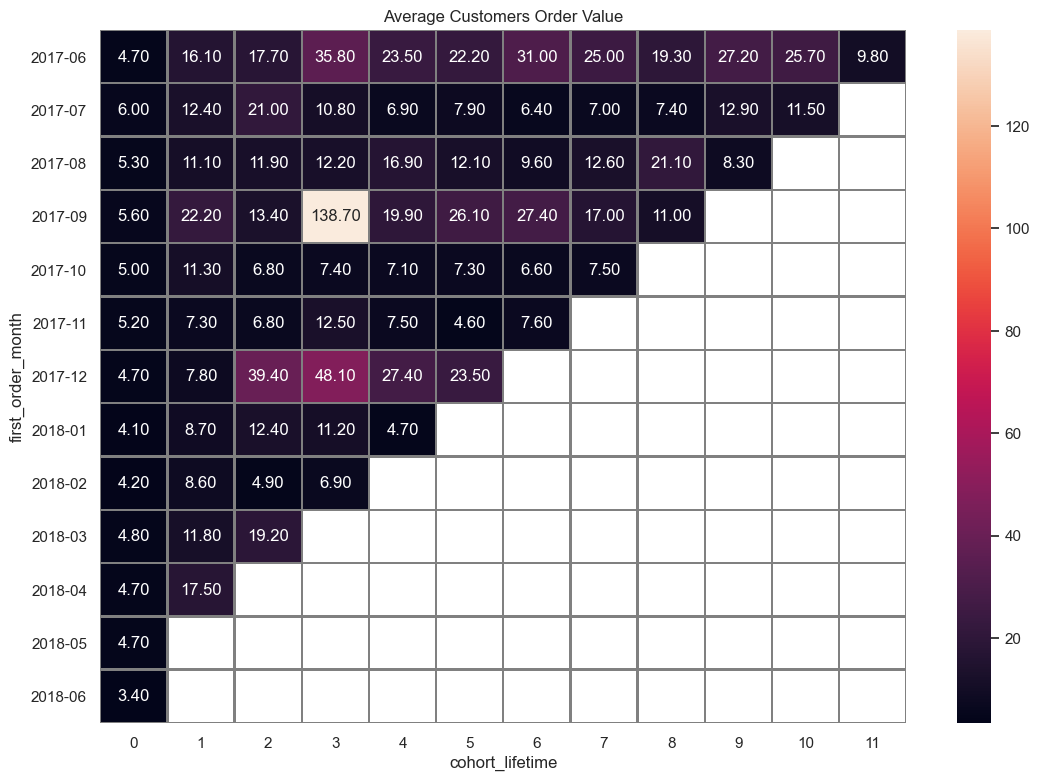

In [77]:
revenue_per_user_pivot = revenue_per_user_pivot

plt.figure(figsize=(13, 9))
plt.title('''Average Customers Order Value''')
sns.heatmap(revenue_per_user_pivot, annot=True, fmt='.2f', linewidths=1, linecolor='gray')

* It is clear that in all cohorts, the average user check increases in the month following the first purchase.
Except for the May 2018 cohort, no purchases took place in the month following the first purchase.

* In the "2018-03" cohorts, the average check increases over time. In the remaining cohorts, the average check fluctuates, with an increase, a decline, and then an increase again.

* The "2017-09" cohort has an abnormally high average check of 138.7.

### Retention Rate by Purchase <a class="anchor" id="3-2-4-bullet"></a>
#### How many customers made repeat purchases over a given period of time?

In [78]:
orders['cohort_lifetime'] = orders['order_month'] - orders['first_order_month']

In [79]:
orders['cohort_lifetime'] = orders['cohort_lifetime'] / np.timedelta64(1,'M')

In [80]:
orders['cohort_lifetime'] = orders['cohort_lifetime'].round().astype('int')

In [81]:
orders['first_order_month'].dt.strftime('%d.%m.%Y')
orders['first_order_month'] = orders['first_order_month'].dt.strftime('%Y-%m')

In [82]:
rate_cohorts = orders.groupby(['first_order_month','cohort_lifetime']).agg({'uid':'nunique'}).reset_index()

In [83]:
inital_users_count = rate_cohorts[rate_cohorts['cohort_lifetime'] == 0][['first_order_month','uid']]


In [84]:
inital_users_count = inital_users_count.rename(columns={'uid':'cohort_users'})
inital_users_count.head()

,first_order_month,cohort_users
0,2017-06,2023
12,2017-07,1923
23,2017-08,1370
33,2017-09,2581
42,2017-10,4340


In [85]:
rate_cohorts = rate_cohorts.merge(inital_users_count,on='first_order_month')

In [86]:
rate_cohorts.head()

,first_order_month,cohort_lifetime,uid,cohort_users
0,2017-06,0,2023,2023
1,2017-06,1,61,2023
2,2017-06,2,50,2023
3,2017-06,3,54,2023
4,2017-06,4,88,2023


In [87]:
rate_cohorts['retention'] = rate_cohorts['uid']/rate_cohorts['cohort_users']
print(rate_cohorts['retention'].mean())

0.1854200310092229


In [88]:
retention_pivot = rate_cohorts.pivot_table(index='first_order_month',columns='cohort_lifetime',values='retention',aggfunc='sum')
retention_pivot.head(15)

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,1.0,0.030153,0.024716,0.026693,0.043500,0.033119,0.030648,0.023233,0.028670,0.022244,0.022244,0.026199
2017-07,1.0,0.027041,0.029641,0.033281,0.025481,0.019761,0.018721,0.020281,0.021841,0.011440,0.013521,NaN
2017-08,1.0,0.042336,0.038686,0.032117,0.029197,0.023358,0.021898,0.032117,0.013869,0.022628,NaN,NaN
2017-09,1.0,0.050368,0.038745,0.028671,0.020147,0.024797,0.025571,0.014336,0.016660,NaN,NaN,NaN
2017-10,1.0,0.047465,0.028341,0.021198,0.021429,0.016590,0.012903,0.015438,NaN,NaN,NaN,NaN
2017-11,1.0,0.054398,0.029405,0.025974,0.019848,0.011762,0.015192,NaN,NaN,NaN,NaN,NaN
2017-12,1.0,0.033311,0.023500,0.022131,0.011408,0.014374,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,1.0,0.033798,0.024607,0.012748,0.013341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,1.0,0.032320,0.015886,0.010682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


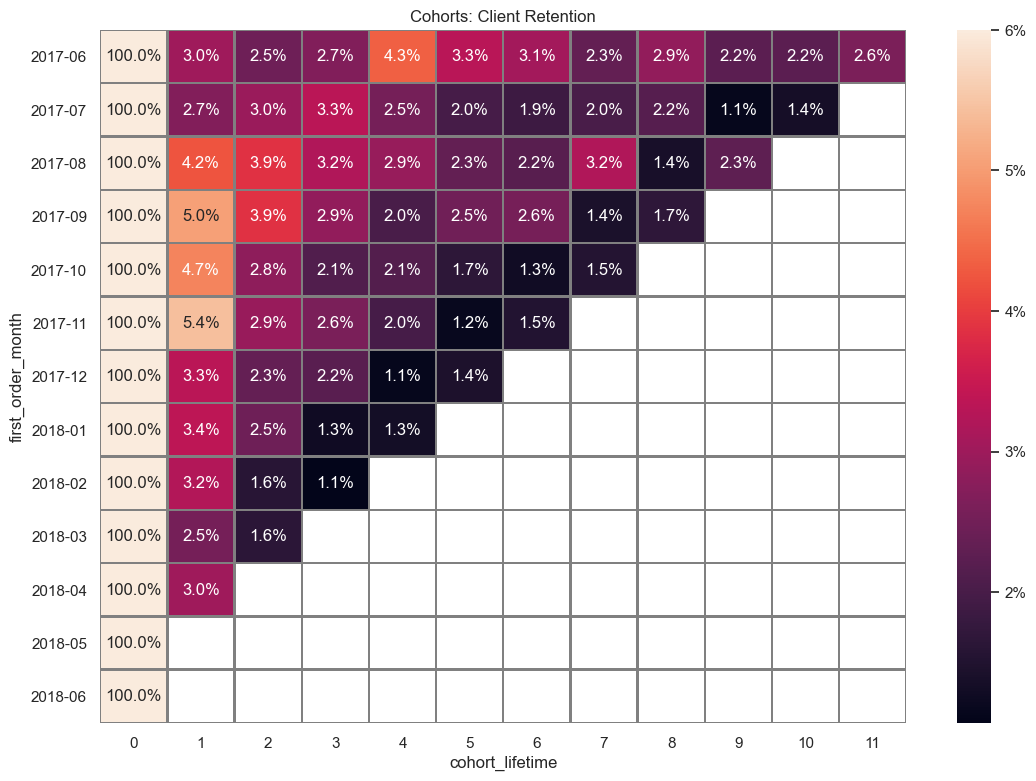

In [89]:
sns.set(style='white')
plt.figure(figsize=(13, 9))
plt.title('Cohorts: Client Retention')
fmt = lambda x,pos: '{:.0%}'.format(x)
heatmap = sns.heatmap(retention_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='gray', vmax=0.06,
            cbar_kws={'format': FuncFormatter(fmt)})

    The retention rate (for customers who have made a purchase) is relatively low in the first month. This is an important signal that we need to focus on customer retention in the first month, as most active customers abandon the service during this period.

    We see that the 2017-11 cohort has the highest rate in the first month of its life – 5.4%.

    Before the 2017-12 cohort, the rate remained between 4% and 5.4%. Starting with the 2017-12 cohort, the rate remained between 3.5% and 2.5%. The retention rate has dropped. This indicates that customer behavior has changed with each new cohort. Perhaps ineffective advertising sources were selected.

    The first cohort, 2017-06, has the highest rate at the time of reporting – 2.6%, a year later.

### Customer Economics: LTV, CAC, ROMI <a class="anchor" id="3-2-5-bullet"></a>

**Data preprocessing**

In [90]:
orders['date'] = orders['date'].dt.date
orders['date'] = pd.to_datetime(orders['date'])

In [91]:
marketing = orders.merge(costs, on='date', how='inner')
marketing.head()

,order_date_t,revenue,uid,date,first_order_date,first_order_month,order_month,cohort_lifetime,source_id,costs
0,2017-06-01 00:10:00,17.0,10329302124590727494,2017-06-01,2017-06-01,2017-06,2017-06-01,0,1,75.20
1,2017-06-01 00:10:00,17.0,10329302124590727494,2017-06-01,2017-06-01,2017-06,2017-06-01,0,2,132.56
2,2017-06-01 00:10:00,17.0,10329302124590727494,2017-06-01,2017-06-01,2017-06,2017-06-01,0,3,349.38
3,2017-06-01 00:10:00,17.0,10329302124590727494,2017-06-01,2017-06-01,2017-06,2017-06-01,0,4,76.74
4,2017-06-01 00:10:00,17.0,10329302124590727494,2017-06-01,2017-06-01,2017-06,2017-06-01,0,5,73.24


In [92]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 352898 entries, 0 to 352897
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date_t       352898 non-null  datetime64[ns]
 1   revenue            352898 non-null  float64       
 2   uid                352898 non-null  uint64        
 3   date               352898 non-null  datetime64[ns]
 4   first_order_date   352898 non-null  datetime64[ns]
 5   first_order_month  352898 non-null  object        
 6   order_month        352898 non-null  datetime64[ns]
 7   cohort_lifetime    352898 non-null  int64         
 8   source_id          352898 non-null  int64         
 9   costs              352898 non-null  float64       
dtypes: datetime64[ns](4), float64(2), int64(2), object(1), uint64(1)
memory usage: 29.6+ MB


In [93]:
marketing['first_order_month'] = pd.to_datetime(marketing['first_order_month'])

**Let's calculate the number of new buyers (n_buyers) for each month**

In [94]:
cohort_sizes = marketing.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']
cohort_sizes.head()

,first_order_month,n_buyers
0,2017-06-01,2023
1,2017-07-01,1923
2,2017-08-01,1370
3,2017-09-01,2581
4,2017-10-01,4340


    Let's group the orders table by the month of the first purchase and the month of each order and sum the revenue.
    Reset the index using the reset_index() method:

In [95]:
cohorts = marketing.groupby(['first_order_month','order_month']).agg({'revenue': 'sum'}).reset_index()
cohorts.head()

,first_order_month,order_month,revenue
0,2017-06-01,2017-06-01,66902.43
1,2017-06-01,2017-07-01,6872.74
2,2017-06-01,2017-08-01,6197.38
3,2017-06-01,2017-09-01,13519.10
4,2017-06-01,2017-10-01,14480.06


    Let's add data to the cohorts table about how many people made a purchase for the first time in each month:

In [96]:
report = pd.merge(cohort_sizes, cohorts, on='first_order_month')
report.head()

,first_order_month,n_buyers,order_month,revenue
0,2017-06-01,2023,2017-06-01,66902.43
1,2017-06-01,2023,2017-07-01,6872.74
2,2017-06-01,2023,2017-08-01,6197.38
3,2017-06-01,2023,2017-09-01,13519.10
4,2017-06-01,2023,2017-10-01,14480.06


    Let's find gross profit by multiplying revenue by marginality. It's more convenient to view LTV by age cohorts, where the columns represent the cohort's age rather than the order month.

In [97]:
margin_rate = 0.5
    
report['gp'] = report['revenue'] * margin_rate
report['age'] = (report['order_month'] - report['first_order_month']) / np.timedelta64(1, 'M')
report['age'] = report['age'].round().astype('int')
report.head()

,first_order_month,n_buyers,order_month,revenue,gp,age
0,2017-06-01,2023,2017-06-01,66902.43,33451.215,0
1,2017-06-01,2023,2017-07-01,6872.74,3436.370,1
2,2017-06-01,2023,2017-08-01,6197.38,3098.690,2
3,2017-06-01,2023,2017-09-01,13519.10,6759.550,3
4,2017-06-01,2023,2017-10-01,14480.06,7240.030,4


    Let's find LTV. Divide the gross profit of the cohorts for each month by the total number of users in each cohort.

In [98]:
report['ltv'] = report['gp'] / report['n_buyers']    
output = report.pivot_table(index='first_order_month', columns='age', values='ltv', aggfunc='mean').round(1)
output.fillna('')

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,16.5,1.7,1.5,3.3,3.6,2.6,3.3,2.0,1.9,2.1,2.0,0.9
2017-07-01,21.0,1.2,2.2,1.3,0.6,0.5,0.4,0.5,0.6,0.5,0.5,
2017-08-01,18.5,1.7,1.6,1.4,1.7,1.0,0.7,1.4,1.0,0.7,,
2017-09-01,19.8,3.9,1.8,13.9,1.4,2.3,2.5,0.9,0.6,,,
2017-10-01,17.5,1.9,0.7,0.6,0.5,0.4,0.3,0.4,,,,
2017-11-01,18.0,1.4,0.7,1.1,0.5,0.2,0.4,,,,,
2017-12-01,16.6,0.9,3.2,3.7,1.1,1.2,,,,,,
2018-01-01,14.5,1.0,1.1,0.5,0.2,,,,,,,
2018-02-01,14.5,1.0,0.3,0.3,,,,,,,,


    Let's calculate the CAC for each cohort. First, find the total expenses for each month, 
    then divide them by the number of customers in each cohort:

In [99]:
monthly_costs = marketing.groupby('order_month')['costs'].sum()
monthly_costs.head(15)

order_month
2017-06-01    1626338.91
2017-07-01    1603972.58
2017-08-01     909936.61
2017-09-01    2918340.48
2017-10-01    6854795.46
2017-11-01    8821592.60
2017-12-01    7827395.31
2018-01-01    5204014.33
2018-02-01    6365115.43
2018-03-01    5682217.14
2018-04-01    2596501.06
2018-05-01    3946823.29
Name: costs, dtype: float64

In [100]:
report_new = pd.merge(report, monthly_costs, left_on='first_order_month', right_on='order_month')
report_new['cac'] = report_new['costs'] / report_new['n_buyers']
report_new.head()

,first_order_month,n_buyers,order_month,revenue,gp,age,ltv,costs,cac
0,2017-06-01,2023,2017-06-01,66902.43,33451.215,0,16.535450,1626338.91,803.924325
1,2017-06-01,2023,2017-07-01,6872.74,3436.370,1,1.698651,1626338.91,803.924325
2,2017-06-01,2023,2017-08-01,6197.38,3098.690,2,1.531730,1626338.91,803.924325
3,2017-06-01,2023,2017-09-01,13519.10,6759.550,3,3.341349,1626338.91,803.924325
4,2017-06-01,2023,2017-10-01,14480.06,7240.030,4,3.578858,1626338.91,803.924325



**Calculate ROMI: Divide LTV by CAC**

In [101]:
report_new['romi'] = report_new['ltv'] / report_new['cac']
output = report_new.pivot_table(
        index='first_order_month', 
        columns='age', 
        values='romi', 
        aggfunc='mean')

output.cumsum(axis=1).round(2)

age,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06-01,0.02,0.02,0.02,0.03,0.03,0.04,0.04,0.04,0.05,0.05,0.05,0.05
2017-07-01,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.03,0.04,NaN
2017-08-01,0.03,0.03,0.03,0.03,0.04,0.04,0.04,0.04,0.04,0.04,NaN,NaN
2017-09-01,0.02,0.02,0.02,0.03,0.04,0.04,0.04,0.04,0.04,NaN,NaN,NaN
2017-10-01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,NaN,NaN,NaN,NaN
2017-11-01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,NaN,NaN,NaN,NaN,NaN
2017-12-01,0.01,0.01,0.01,0.01,0.01,0.01,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-01,0.01,0.01,0.01,0.01,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,0.01,0.01,0.01,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


    We see that more than one cohort failed to break even.
    The maximum ROMI of 0.05 was for the first cohort on June 1, 2017, at nine months of age.
    The next cohort had a ROMI of 0.04 (for three cohorts: July 1, 2017, August 1, and September 1).
    The cohort on April 1, 2018, had a ROMI of 0.02 at two months of age.
    All other cohorts had a ROMI of 0.01.

### 3.3. Marketing<a class="anchor" id="3-3-bullet"></a>

### Advertising Costs
### Total / by Source / by Time <a class="anchor" id="3-3-1-bullet"></a>

    Let's create a table with expenses and revenue to see the total revenue and total costs.

In [102]:
costs_copy = costs.copy()
costs_copy['date'] = costs_copy['date'].values.astype('datetime64[M]') 
costs_grouped = costs_copy.groupby('date').agg({'costs': 'sum'})

In [103]:
orders_grouped = orders.groupby('date').agg({'revenue': 'sum'})

In [104]:
data = {'summary': [round(orders_grouped.sum().values[0], 2),round(costs_grouped.sum().values[0], 2)]}
rev_costs = pd.DataFrame(data=data, index=['revenue', 'costs'])

In [105]:
rev_costs.head()

,summary
revenue,252057.20
costs,329131.62


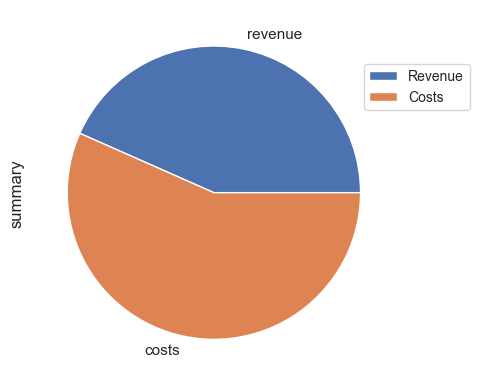

In [106]:
rev_costs.plot(kind='pie', y='summary', grid=True, figsize=(6, 4))
plt.tight_layout(pad=1)
plt.legend(['Revenue', 'Costs'], bbox_to_anchor=(0.89,0.87), prop={'size':10})

    We see that the total amount of expenses on advertising sources exceeds the total revenue.


**Amount of expenses for each type of advertising source**

In [107]:
source_id_cost = costs.groupby('source_id').agg({'costs': 'sum'}).round(2).sort_values(by='costs', ascending=False)
source_id_cost.head(9)

,costs
source_id,
3,141321.63
4,61073.60
5,51757.10
2,42806.04
1,20833.27
10,5822.49
9,5517.49


Text(0.5, 1.0, 'Costs by Advertising Source')

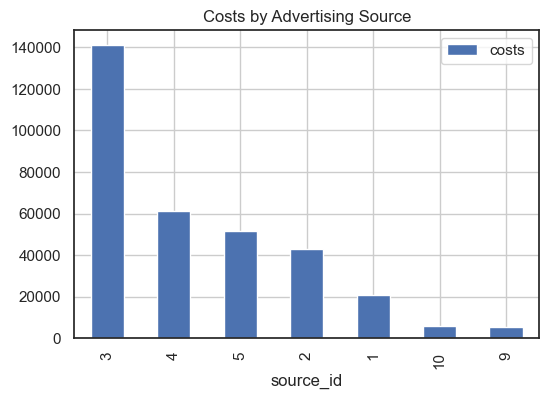

In [108]:
source_id_cost = costs.groupby('source_id').agg({'costs': 'sum'}).round(2).sort_values(by='costs', ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Costs by Advertising Source')

* The most money was spent on the 3rd source.
* The next largest costs were sources 4 and 5.
* The top 2 cheapest sources of attraction were 10 and 9.


**Amount of expenses on advertising sources by time (broken down by year and month)**

In [109]:
costs['month'] = costs['date'].dt.month
costs['year']  = costs['date'].dt.year

In [110]:
year_cost = costs.groupby('year').agg({'costs': 'sum'}).round(2).sort_values(by='costs', ascending=False)
year_cost.head(3)

,costs
year,
2017,187961.15
2018,141170.47


Text(0.5, 1.0, 'Advertising Costs by Year')

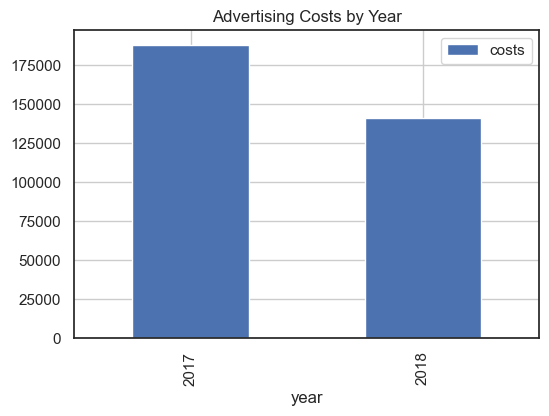

In [111]:
year_cost = costs.groupby('year').agg({'costs': 'sum'}).sort_values(by='costs', ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Advertising Costs by Year')

    For the 2017 reporting period, it was 7 months; for the 2018 reporting period, it was 5 months.
    Logically, advertising costs were higher in 2017.
    Let's look at the average costs for the year:

Text(0.5, 1.0, 'Average Monthly Advertising Costs by Year')

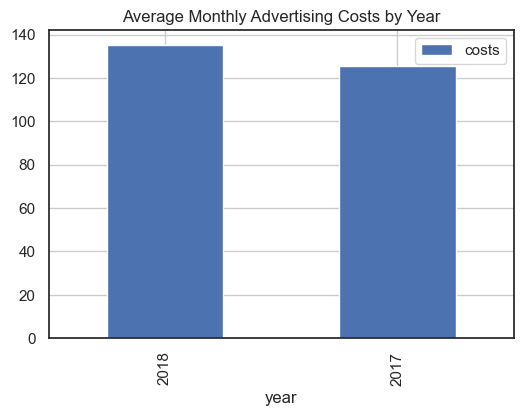

In [113]:
year_cost_mean = costs.groupby('year').agg({'costs': 'mean'}).sort_values(by='costs', ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Average Monthly Advertising Costs by Year')

    The difference in advertising costs between 2017 and 2018 narrowed.
    Let's look at the costs by month in each year:

In [114]:
month_cost = costs.groupby(['year', 'month']).agg({'costs': 'sum'}).round(2)
month_cost.head(20)

costs
year month          
2017 6      18015.00
     7      18240.59
     8      14790.54
     9      24368.91
     10     36322.88
     11     37907.88
     12     38315.35
2018 1      33518.52
     2      32723.03
     3      30415.27
     4      22289.38
     5      22224.27

Text(0.5, 1.0, 'Advertising Costs by Month')

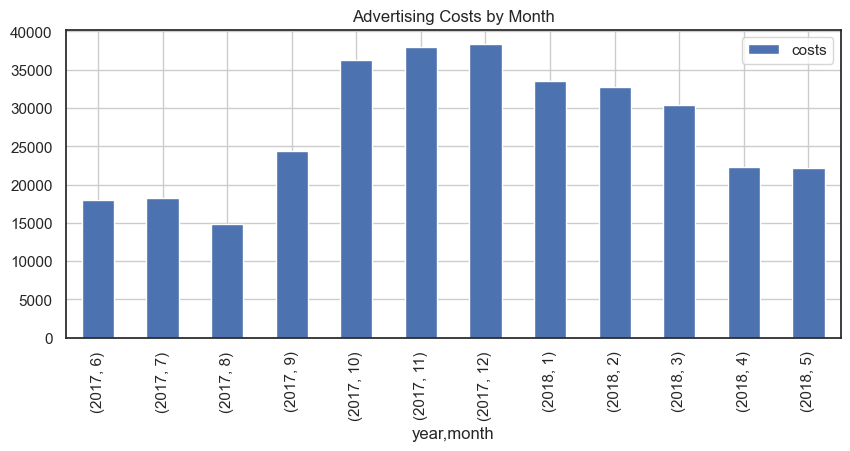

In [116]:
month_cost = costs.groupby(['year', 'month']).agg({'costs': 'sum'}).plot(kind='bar', grid=True, figsize=(10, 4))
plt.title('Advertising Costs by Month')

* Top 3 months by advertising spend: November, December, and October 2017
* Top 3 months by lowest advertising spend: August, July, and June 2017
* Advertising spend decreased in the last two months of 2018 (April and May) compared to previous months

**Costs by advertising sources in dynamics**

Text(0.5, 1.0, 'Advertising Costs by Source and Month')

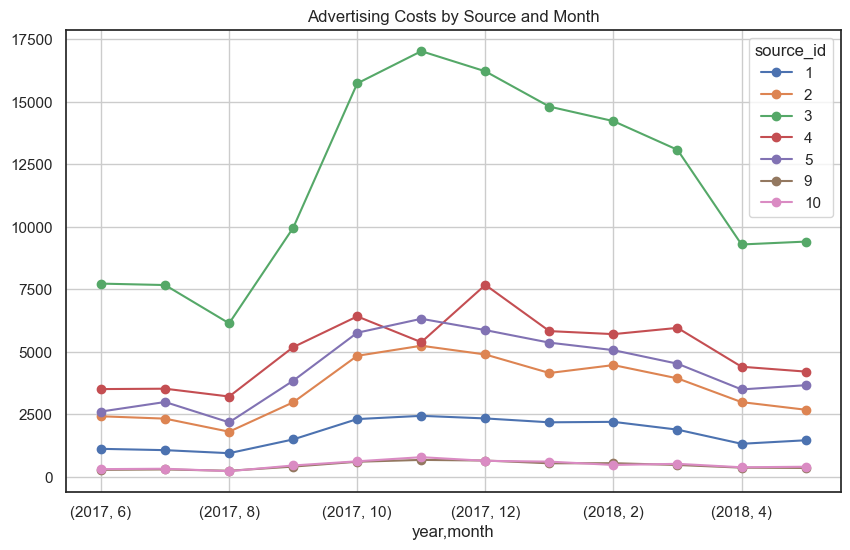

In [117]:
costs.pivot_table(index=['year', 'month'], columns='source_id', values='costs', aggfunc='sum').plot(style='o-', grid=True, figsize=(10, 6))
plt.title('Advertising Costs by Source and Month')

    First group:
    Sources 10 and 9 (the lines coincide on the graph) show a flat trend, without any ups or downs. We also see that this source has the lowest cost level.

    Source 1 is very similar to sources 10 and 9, but its cost level is slightly higher. There are also slight changes in the trend. There is a slight drop in August 2017, followed by a slight increase until March 2018, then a further decline.

    Second group:
    Sources 2, 5, and 4. These sources are very similar in their trend, with similar increases and declines. The exception is November 2017, when source 4 experienced a decline, and December 2017, when it experienced an increase.

    Third group:
    Source 3 is the most expensive. Its trend differs from the others. After August 2017, there is a sharp increase in costs. Spending peaked in September 2018. A significant decline began after March 2018.

    General trends:
    All advertising sources experienced a decrease in spending - August 2017, December 2017, April 2018
    All advertising sources experienced an increase in spending - September 2017, October 2017

### Cost per Customer Acquisition<a class="anchor" id="3-3-2-bullet"></a>

In [118]:
marketing['month'] = marketing['date'].dt.month
marketing['year']  = marketing['date'].dt.year

In [119]:
cost_uid_sourse = marketing.groupby('source_id').agg({'uid':'nunique', 'costs': 'mean'}).round(2).sort_values(by='costs', ascending=False)
cost_uid_sourse.head(10)

,uid,costs
source_id,,
3,36522,469.05
4,36522,188.89
5,36522,172.69
2,36522,141.71
1,36522,69.08
10,36522,18.94
9,36522,17.86


Text(0.5, 1.0, 'Cost of Attracting One Buyer from Different Sources')

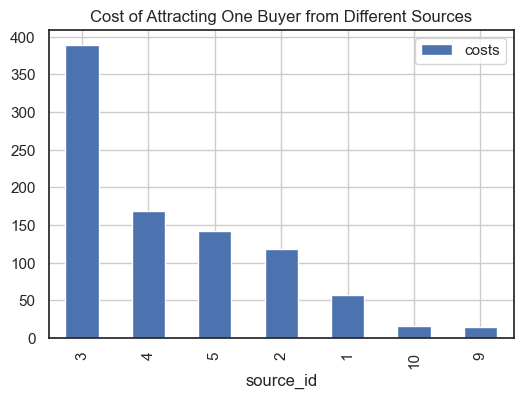

In [120]:
cost_uid_sourse = costs.groupby('source_id').agg({'costs': 'mean'}).round(2).sort_values(by='costs', ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Cost of Attracting One Buyer from Different Sources')

* On average, the highest costs per customer come from source 3.
* Sources 4 and 5 come in second and third.
* On average, the lowest costs per customer come from sources 10 and 9.

### ROMI, Return on Advertising Spend <a class="anchor" id="3-3-3-bullet"></a>

In [121]:
# customers by source
visits_sorted = visits.sort_values(by='session_start_t')

In [122]:
# costs by source
costs_per_source = costs.groupby('source_id').agg({'costs': 'sum'})

In [123]:
# revenue by source
first_source_per_user = visits_sorted.groupby('uid').agg({'source_id': 'first'})
client_per_source = orders.merge(first_source_per_user, on='uid')
client_per_source = client_per_source.groupby('source_id').agg({'uid': 'nunique'})

In [124]:
# unique users by source
uid_per_source = visits_sorted.groupby('source_id').agg({'uid': 'nunique'})
rev_per_source = orders.merge(first_source_per_user, on='uid')
rev_per_source = rev_per_source.groupby('source_id').agg({'revenue': 'sum'})
rev_uid_costs_per_source = pd.concat([costs_per_source, rev_per_source, 
                                      client_per_source],axis=1).fillna(0)
rev_uid_costs_per_source = rev_uid_costs_per_source.reset_index()
rev_uid_costs_per_source.head()

,source_id,costs,revenue,uid
0,1,20833.27,31090.55,2899
1,2,42806.04,46923.61,3506
2,3,141321.63,54511.24,10473
3,4,61073.60,56696.83,10296
4,5,51757.10,52624.02,6931


### LTV for each advertising source

In [125]:
rev_uid_costs_per_source['ltv'] = (rev_uid_costs_per_source['revenue'] / rev_uid_costs_per_source['uid']).round(3)
rev_uid_costs_per_source.head(15)

,source_id,costs,revenue,uid,ltv
0,1,20833.27,31090.55,2899,10.725
1,2,42806.04,46923.61,3506,13.384
2,3,141321.63,54511.24,10473,5.205
3,4,61073.60,56696.83,10296,5.507
4,5,51757.10,52624.02,6931,7.593
5,7,0.00,1.22,1,1.220
6,9,5517.49,5759.40,1088,5.294
7,10,5822.49,4450.33,1329,3.349


<AxesSubplot:xlabel='source_id'>

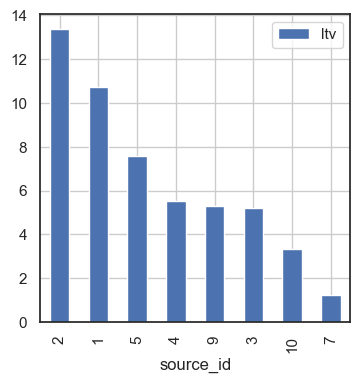

In [126]:
rev_uid_costs_per_source.sort_values(by='ltv', ascending=False).plot(x='source_id', y='ltv', kind='bar', grid=True, figsize=(4, 4))

### CAC for each advertising source

In [127]:
rev_uid_costs_per_source['cac'] = (rev_uid_costs_per_source['costs'] / rev_uid_costs_per_source['uid']).round(1)
rev_uid_costs_per_source.head(15)

,source_id,costs,revenue,uid,ltv,cac
0,1,20833.27,31090.55,2899,10.725,7.2
1,2,42806.04,46923.61,3506,13.384,12.2
2,3,141321.63,54511.24,10473,5.205,13.5
3,4,61073.60,56696.83,10296,5.507,5.9
4,5,51757.10,52624.02,6931,7.593,7.5
5,7,0.00,1.22,1,1.220,0.0
6,9,5517.49,5759.40,1088,5.294,5.1
7,10,5822.49,4450.33,1329,3.349,4.4


<AxesSubplot:xlabel='source_id'>

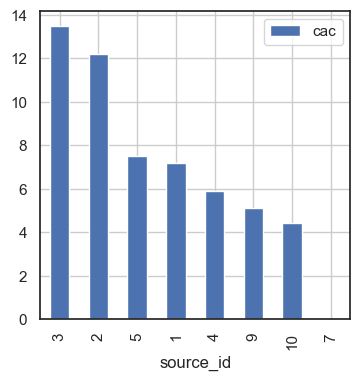

In [128]:
rev_uid_costs_per_source.sort_values(by='cac', ascending=False).plot(x='source_id', y='cac', kind='bar', grid=True, figsize=(4, 4))

### ROMI for each advertising source (using a simplified formula)

In [129]:
rev_uid_costs_per_source['romi'] = (rev_uid_costs_per_source['revenue'] / rev_uid_costs_per_source['costs']).round(1)
rev_uid_costs_per_source.head(15)

,source_id,costs,revenue,uid,ltv,cac,romi
0,1,20833.27,31090.55,2899,10.725,7.2,1.5
1,2,42806.04,46923.61,3506,13.384,12.2,1.1
2,3,141321.63,54511.24,10473,5.205,13.5,0.4
3,4,61073.60,56696.83,10296,5.507,5.9,0.9
4,5,51757.10,52624.02,6931,7.593,7.5,1.0
5,7,0.00,1.22,1,1.220,0.0,inf
6,9,5517.49,5759.40,1088,5.294,5.1,1.0
7,10,5822.49,4450.33,1329,3.349,4.4,0.8


<AxesSubplot:xlabel='source_id'>

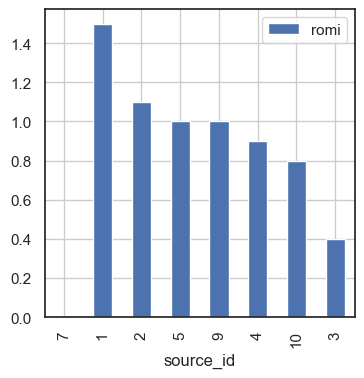

In [130]:
rev_uid_costs_per_source.sort_values(by='romi', ascending=False).plot(x='source_id', y='romi', kind='bar', grid=True, figsize=(4, 4))

    Advertising sources 9 and 10 have the lowest costs. However, they don't generate much revenue, so they are not optimal. (Based on ROMI, source 9 is in 4th place, and source 10 is second to last.)

    The top 3 sources by revenue-to-cost ratio are:
    channels 1, 2, and 5.

    Channel 3 turned out to be the least effective. It is the most expensive and yet ranks only 6th in revenue.

###  Analysis of Resource Traffic by Device Type<a class="anchor" id="3-3-4-bullet"></a>

In [131]:
visits_by_device = visits.groupby('device').agg({'uid': 'count'})
visits_by_device

,uid
device,
desktop,262567
touch,96833


We see that in 73.06% of cases the service was visited from a PC, and in 26.94% of cases the site was visited from mobile devices.

**Total Yandex.Afisha revenue by device type**

In [132]:
sales_device = sales.groupby('device').agg({'revenue': 'sum'}).round(2)
sales_device

,revenue
device,
desktop,6447893.99
touch,514313.36


Text(0.5, 1.0, "Yandex.Afisha's Total Revenue\n by Device Type")

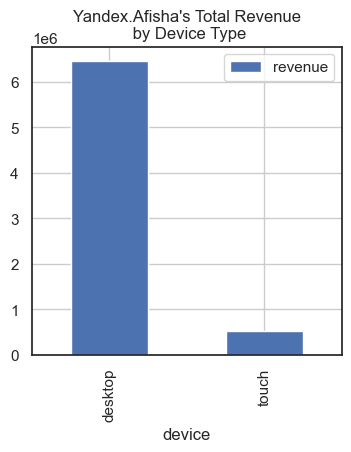

In [136]:
sales_device = sales.groupby('device').agg({'revenue': 'sum'}).plot(kind='bar', grid=True, figsize=(4, 4))
plt.title('''Yandex.Afisha's Total Revenue\n by Device Type''')

**Total revenue of Yandex.Afisha by device type, by year**

In [137]:
sales.pivot_table(index='year', columns='device', values='revenue', aggfunc='sum').round(1)

device,desktop,touch
year,,
2017,3522678.7,295414.5
2018,2925215.3,218898.8


Text(0.5, 1.0, 'Yandex.Afisha revenue by Device Type and Year')

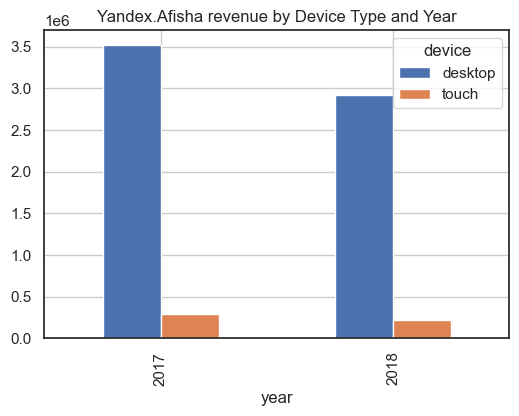

In [138]:
sales.pivot_table(index='year', columns='device', values='revenue', aggfunc='sum').plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Yandex.Afisha revenue by Device Type and Year')

**Total Yandex.Afisha revenue by device type, by year and month**

In [139]:
sales.pivot_table(index=('year', 'month'), columns='device', values='revenue', aggfunc='sum').round(1)

device        desktop     touch
year month                     
2017 6       243927.0    9397.5
     7       214176.8    9754.2
     8       214823.8   13634.4
     9       664880.9   25031.3
     10      515669.9   81307.1
     11      631210.6  102463.8
     12     1037989.7   53826.3
2018 1       572842.8   36077.3
     2       694623.9   32254.5
     3       623383.3   58243.6
     4       511988.1   37637.6
     5       522377.2   54685.9

<AxesSubplot:xlabel='year,month'>

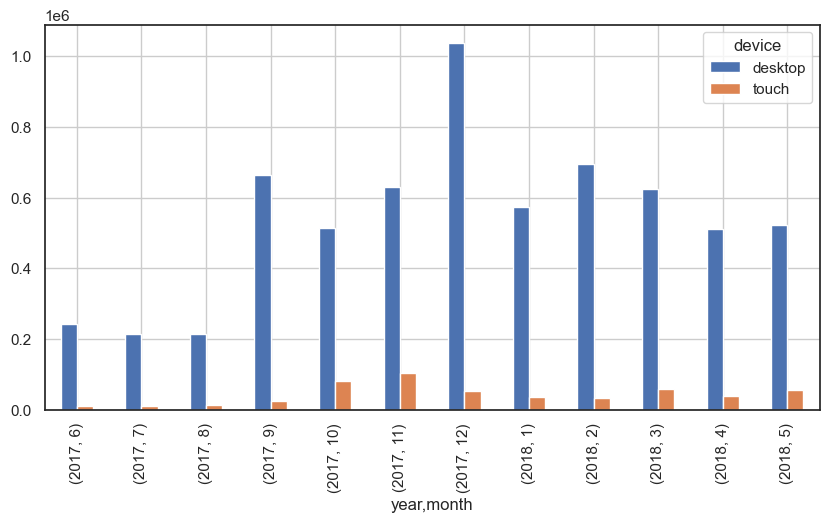

In [140]:
sales.pivot_table(index=('year', 'month'), columns='device', values='revenue', aggfunc='sum').plot(kind='bar', grid=True, figsize=(10, 5))

    We see that Yandex.Afisha users primarily use PCs and rarely access the service on mobile phones. 
    Perhaps the mobile version of the site isn't user-friendly enough, making it more difficult to place orders. Let's look at the visits table to see the number of sessions on PCs
    and mobile phones, as well as their duration.

In [141]:
visits.groupby('device').agg({'session_duration_sec':'sum', 'session_start_t':'count'})

,session_duration_sec,session_start_t
device,,
desktop,184833246,262567
touch,46442986,96833


* The number of sessions on a PC is 2.7 times greater.
* The duration of sessions on a PC is 51 342.6 hours.
* The duration of sessions on a mobile phone is 12 900.8 hours.
Accordingly, the duration of sessions on a PC is 4 times greater.

## Step 4. General Conclusion<a class="anchor" id="4-bullet"></a>

The average session duration is 60 seconds.
On average, users start buying within a minute of starting a session. This means they know exactly what they want to buy.

***DAU***, number of unique users per day: 908

***WAU***, number of unique users per week: 5 716

***MAU***, number of unique users per month: 23 228

***Sticky Factor*** (monthly) - 3.9%

A normal sticky factor (monthly) is around 20-18%. In this case, it's 3.9%, meaning users only visited once per month on average.

After the first month, the number of visitors and buyers in the cohort drops significantly.

***Retention by visits*** In the first month, we see a low retention rate:
* before December 2017 - from 7.7% to 8.5% (except for July 2017 - 5.6%)
* since December 2017 - from 6% to 4.2%

This is an important signal that we need to focus on retaining customers in the first month, as the majority of active customers abandon the service during this period.
The first cohort has the highest retention rate even after a year - 4.5%.

At the same time, in all cohorts, the ***average order value*** of users increases in the month following the first purchase. In the "2018-03" cohorts, the average order value increases over time. In the remaining cohorts, the average order value fluctuates, sometimes rising, then declining, and then rising again.

Since December 2017, the number of customers in each subsequent cohort has been declining. This means that Yandex.Afisha is attracting fewer and fewer new customers over time.

***The first cohort*** brings in the most money even after a year of cohort existence.
The first cohort has the highest retention rate after a year. It's necessary to study the first cohort in more detail and identify the factors that retain it.

***Advertising Sources***

Top 3 Months by Advertising Source Spend: November, December, October 2017

Advertising sources 9 and 10 spend the least. However, they don't generate much revenue, so they aren't optimal. (Based on ROMI, source 9 is in 4th place, and source 10 is second to last.)

Top 3 sources by revenue-to-cost ratio: channels 1, 2, and 5.

Channel 3 turned out to be the least effective channel. It's the most expensive, yet only ranks 6th in revenue.

***Devices***

Users access Yandex.Afisha primarily via PCs and rarely access it via mobile devices. Perhaps the mobile version of the site isn't user-friendly enough, making it more difficult to place orders.

• The number of sessions on PCs is 2.7 times higher than on mobile devices.
• Session duration on PCs is 4 times longer than on mobile devices.